# Лабораторная работа 1

In [91]:
pip install pymorphy2

Note: you may need to restart the kernel to use updated packages.


In [2]:
# pip install gensim

In [92]:
from IPython.display import FileLink
import pandas as pd
import numpy as np
import gensim
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from nltk.tokenize import word_tokenize
import re
import joblib
import nltk
from nltk.corpus import stopwords
from pymorphy2 import MorphAnalyzer
from nltk.stem.snowball import RussianStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import pymorphy2
from collections import Counter
from tqdm.auto import tqdm
from gensim.models import FastText

tqdm.pandas()

## 1.1 Извлечение признаков из текста

In [93]:
df1 = pd.read_csv('/kaggle/input/rubsova-twit/negative.csv', delimiter=';', names=['id', 'date', 'name', 'text', 'typr', 'rep', 'rtw', 'faw', 'stcount', 'foll', 'frien', 'listcount'])
df2 = pd.read_csv('/kaggle/input/rubsova-twit/positive.csv', delimiter=';', names=['id', 'date', 'name', 'text', 'typr', 'rep', 'rtw', 'faw', 'stcount', 'foll', 'frien', 'listcount'])
df = pd.concat([df1, df2])
df = df.drop(['id', 'date', 'name', 'rep', 'rtw', 'faw', 'stcount', 'foll', 'frien', 'listcount'], axis=1)

In [30]:
df

,text,typr
0,на работе был полный пиддес :| и так каждое за...,-1
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",-1
2,@elina_4post как говорят обещаного три года жд...,-1
3,"Желаю хорошего полёта и удачной посадки,я буду...",-1
4,"Обновил за каким-то лешим surf, теперь не рабо...",-1
...,...,...
114906,"Спала в родительском доме, на своей кровати......",1
114907,RT @jebesilofyt: Эх... Мы немного решили сокра...,1
114908,"Что происходит со мной, когда в эфире #proacti...",1
114909,"""Любимая,я подарю тебе эту звезду..."" Имя како...",1


## 1.2 Предобработка текста: удаление стоп-слов, токенизация, лемматизация

In [32]:
stop_words = set(stopwords.words('russian'))
stop = []
for i in stop_words:
  if i not in ['нет','не','хорошо','иногда',
               'наконец','ни','никогда','ничего',
               'опять','разве','совсем','уже']:
      stop.append(i)
      
morph = MorphAnalyzer()
stemmer = RussianStemmer(True)

def norm(line, stop_words=stop):
  line = line.lower()
  line = re.sub('[^ЙйёЁА-Яа-я0-9 ]', '', line)
  line = re.sub('\s+', ' ', line).strip()
  line = [i for i in line.split() if i not in stop_words]
  line = [morph.parse(word)[0].normal_form for word in line]
  # line = [stemmer.stem(word) for word in line]
  return ' '.join(line)

# df['clean_text'] = df['text'].apply(norm)
# df.to_csv('normed.csv', index=False)

In [13]:
# stop_words

In [16]:
print('Original:\t', df.iloc[0]['text'])
print('Normed:\t\t', norm(df.iloc[0]['text']))

Original:	 на работе был полный пиддес :| и так каждое закрытие месяца, я же свихнусь так D:
Normed:		 работа полный пиддес каждый закрытие месяц свихнуться


In [ ]:
df

## LinisCrowd

In [94]:
vocab = pd.read_csv('/kaggle/input/nlp-1-lw/words_all_full_rating.csv', encoding='windows-1251', delimiter=';')
vocab['mean'] = vocab['mean'].str.replace(',', '.').astype(float)
vocab = dict(zip(vocab['Words'], vocab['mean']))

In [95]:
vocab[norm('аборигенный')]

-0.25

In [97]:
df = pd.read_csv('/kaggle/input/rubsova-twit/features.csv')

In [98]:
df['clean_text']

0         работа полный пиддес каждый закрытие месяц сви...
1          коллега сидеть рубиться изз долбать винд не мочь
2                             4 говорить обещаной год ждать
3         желать хороший полёт удачный посадкия быть оче...
4           обновить какимтый леший не работать простоплеер
                                ...                        
226829    спасть родительский дом свой кровать проснутьс...
226830    эх немного решить сократить путь уже лежать мя...
226831         происходить я эфир звучать любимый песня 655
226832    любимаять подарить ты звезда имя звезда перево...
226833    посмотреть непытайтесьпокинутьомск сегодня вав...
Name: clean_text, Length: 226834, dtype: object

In [99]:
df['liniscrowd'] = df['clean_text'].apply(lambda x: [round(vocab.get(x_split, 0), 2) for x_split in str(x).split(' ')])

In [100]:
def liniscrowd_upd(x):
    res = []
    res.append(np.mean(x))
    res.append(max(x))
    res.append(min(x))
    res.append(sum(x))
    res.append(sum([1 if i>0 else 0 for i in x]))
    res.append(sum([1 if i<0 else 0 for i in x]))
    return res

In [101]:
df['liniscrowd_upd'] = df['liniscrowd'].apply(liniscrowd_upd)

In [102]:
df['liniscrowd_upd']

0               [0.055714285714285716, 0.22, 0, 0.39, 2, 0]
1                             [-0.025, 0, -0.2, -0.2, 0, 1]
2                                    [0.0, 0, 0, 0.0, 0, 0]
3         [0.22199999999999998, 1.22, 0, 2.2199999999999...
4                                    [0.0, 0, 0, 0.0, 0, 0]
                                ...                        
226829                               [0.0, 0, 0, 0.0, 0, 0]
226830        [0.02153846153846154, 0.5, -0.22, 0.28, 1, 1]
226831                          [0.19, 1.33, 0, 1.33, 1, 0]
226832                            [0.25, 1.0, 0, 2.0, 2, 0]
226833                                 [0.0, 0, 0, 0, 0, 0]
Name: liniscrowd_upd, Length: 226834, dtype: object

## PoS

In [21]:
def get_pos_frequencies(text):
    words = text.split() 
    pos_counts = Counter()
    for word in words:
        parsed_word = morph.parse(word)[0]
        pos_counts[parsed_word.tag.POS] += 1

    total_words = sum(pos_counts.values())
    if total_words > 0:
        pos_freq = {pos: count / total_words for pos, count in pos_counts.items()}
    else:
        pos_freq = {}
    return pos_freq

In [22]:
get_pos_frequencies('Что происходит со мной, когда в эфире')

{'CONJ': 0.2857142857142857,
 'VERB': 0.14285714285714285,
 'PREP': 0.2857142857142857,
 None: 0.14285714285714285,
 'NOUN': 0.14285714285714285}

In [ ]:
df['pos_frequencies'] = df['text'].apply(get_pos_frequencies)
df_pos = df['pos_frequencies'].apply(pd.Series).fillna(0)
df = pd.concat([df, df_pos], axis=1).drop(columns=['pos_frequencies'])

In [ ]:
texts = df['clean_text'].fillna('')

## Tf-Idf

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(texts)

In [ ]:
svd = TruncatedSVD(n_components=1000, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

In [ ]:
joblib.dump(X_reduced, "X_reduced.npy")

In [ ]:
FileLink('X_reduced.npy')

In [ ]:
# df2 = pd.concat([df[['text', 'typr','clean_text']].reset_index(drop=True), df_tfidf.reset_index(drop=True)], axis=1)
# df2.to_csv('features_tfidf.csv', index=False)

In [ ]:
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(svd, 'svd_model.pkl')

## My Word2Vec

In [ ]:
# pip install gensim nltk

In [5]:
df = pd.read_csv('/kaggle/input/rubsova-twit/normed.csv')

In [6]:
df['tokens'] = df['clean_text'].apply(lambda x: str(x).split())

In [ ]:
w2v_model = Word2Vec(sentences=df['tokens'], vector_size=100, window=5, min_count=2, workers=4)

In [ ]:
def get_w2v_vector(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

In [ ]:
df['w2v_features'] = df['tokens'].apply(lambda x: get_w2v_vector(x, w2v_model))
df.to_csv('my_w2v.csv', index=False)

In [ ]:
joblib.dump(w2v_model, 'my_w2v_model.pkl')

In [ ]:
w2v_model_loaded['привет']

In [24]:
pd.read_csv('/kaggle/input/nlp-1-lw/my_w2v.csv')['w2v_features']

0         [ 0.04113258  0.4107082  -0.15015504 -0.051603...
1         [ 0.05588531  0.5537307   0.19449191 -0.266300...
2         [-0.09966431  1.273266   -0.5653407   0.479176...
3         [ 0.03593685  0.64653337 -0.15462223  0.265323...
4         [ 5.0608758e-02  3.7173828e-01  4.8490760e-01 ...
                                ...                        
226829    [ 1.9891323e-01  2.6349968e-01 -9.5659368e-02 ...
226830    [ 0.01340473  0.29347783  0.05900931 -0.155121...
226831    [-4.91974503e-01  6.73228443e-01  1.81374326e-...
226832    [-0.06378706  0.7570992   0.10845997 -0.024873...
226833    [ 0.00347985  0.13983686  0.28848213 -0.002476...
Name: w2v_features, Length: 226834, dtype: object

## W2V

In [26]:
def get_w2v_vector2(tokens, model, vector_size=100):
    vectors = [model.get_vector(get_index(word)) for word in tokens if get_index(word) != 'NONE']
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

    
w2v_model_loaded = KeyedVectors.load_word2vec_format("/kaggle/input/nlp-1-lw/model.bin", encoding='utf-8', unicode_errors='ignore', binary=True)
w2v_model_loaded.init_sims(replace=True)

<ipython-input-26-cc7cbbce2c44>:7: DeprecationWarning: Call to deprecated `init_sims` (Use fill_norms() instead. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  w2v_model_loaded.init_sims(replace=True)


In [27]:
keys = list(w2v_model_loaded.key_to_index.keys())
values = [i.split('_')[0] for i in keys]
indexes = dict(zip(values, keys))

def get_index(word, indexes=indexes):
    word = str(word).lower()
    return indexes.get(word, 'NONE')


get_index('Привет')

'привет_VERB'

In [28]:
df['w2v_features'] = df['tokens'].progress_apply(lambda x: get_w2v_vector2(x, w2v_model_loaded))

  0%|          | 0/226834 [00:00<?, ?it/s]

In [29]:
df.to_csv('w2v.csv', index=False)

## My Fast Text

In [32]:
corpus = df['tokens']
model = FastText(vector_size=100, window=5, min_count=1, workers=4)
model.build_vocab(corpus)  # Создание словаря
model.train(corpus, total_examples=len(corpus), epochs=10)  # Обучение
model.save("myfasttext.bin")

In [40]:
def get_ft_vector(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

In [41]:
df['ft_features'] = df['tokens'].progress_apply(lambda x: get_ft_vector(x, model))
df.to_csv('my_ft.csv', index=False)

  0%|          | 0/226834 [00:00<?, ?it/s]

In [42]:
FileLink('my_ft.csv')

/kaggle/working/my_ft.csv

## FT

In [7]:
import fasttext
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(repo_id="facebook/fasttext-ru-vectors", filename="model.bin")
model = fasttext.load_model(model_path)

model.bin:   0%|          | 0.00/7.26G [00:00<?, ?B/s]

In [18]:
def get_ft_vector(tokens, model, vector_size=100):
    vectors = [model[word] for word in tokens]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

In [19]:
df['ft_features'] = df['tokens'].progress_apply(lambda x: get_ft_vector(x, model))

  0%|          | 0/226834 [00:00<?, ?it/s]

In [20]:
df.to_csv('ft.csv', index=False)

# Training

In [103]:
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, f1_score
import torch.utils.data as data_utils
import torch.optim as optim
import joblib
from catboost import CatBoostClassifier

In [104]:
ds = pd.read_csv('/kaggle/input/rubsova-twit/features.csv')

In [71]:
def pool(x, dim=27):
    while len(x) != dim:
        x.append(0)
    return x

In [57]:
class EXP():
    def __init__(self):
        self.batch_size = 64
        self.loss_function = nn.NLLLoss()  # Используем NLLLoss
        self.lr = 1e-5
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Используем GPU, если доступен

    def get_dataloaders(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
        self.y_test = y_test
        
        inputs_train = torch.tensor(X_train, dtype=torch.float32).to(self.device)
        targets_train = torch.tensor(y_train, dtype=torch.long).to(self.device)
        inputs_test = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        targets_test = torch.tensor(y_test, dtype=torch.long).to(self.device)

        train = data_utils.TensorDataset(inputs_train, targets_train)
        test = data_utils.TensorDataset(inputs_test, targets_test)

        self.trainset = torch.utils.data.DataLoader(train, batch_size=self.batch_size, shuffle=True)
        self.testset = torch.utils.data.DataLoader(test, batch_size=self.batch_size, shuffle=False)
        self.input_dim = inputs_train.shape[-1]

    def get_model(self):
        self.model = classifier(self.input_dim).to(self.device)  # Переносим модель на GPU, если возможно
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

    def train(self, epochs=5):
        for epoch in range(epochs):
            with tqdm(self.trainset, desc=f"Epoch {epoch+1}/{epochs}", leave=True) as pbar:
                for X, y in pbar:
                    X, y = X.to(self.device), y.to(self.device)
                    self.model.zero_grad()
                    output = self.model(X)
                    log_output = torch.log_softmax(output, dim=1)  # Применяем log_softmax
                    loss = self.loss_function(log_output, y)  # Вычисляем потерю
                    loss.backward()
                    self.optimizer.step()
                    pbar.set_postfix(loss=loss.item()) 

    def test(self):
        self.model.eval()
        predictions, targets = [], []

        with torch.no_grad():
            for X, y in self.testset:
                X, y = X.to(self.device), y.cpu()
                output = self.model(X)
                log_output = torch.log_softmax(output, dim=1)  # Применяем log_softmax
                preds = torch.argmax(log_output, dim=1)
                predictions.extend(preds.cpu().numpy())  # Переносим на CPU для расчета
                targets.extend(y.cpu().numpy())

        # Вычисляем F1-score
        self.f1 = f1_score(targets, predictions, average="weighted")  # Для многоклассовой классификации
        print(f"F1 Score: {self.f1:.4f}")

        # Выводим отчёт
        print(classification_report(targets, predictions))

In [58]:
class classifier(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128) 
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=128, nhead=4), num_layers=2
        )
        self.fc2 = nn.Linear(128, num_classes)  
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.fc1(x))  
        x = x.unsqueeze(0)  
        x = self.transformer(x)
        x = x.mean(dim=0)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## Linis Crowd

In [6]:
X = [pool(eval(i)) for i in ds['liniscrowd'].tolist()]
y = ds['typr'].tolist()
y = [(i + 1) // 2 for i in y]

In [7]:
model_1 = EXP()
model_1.get_dataloaders(X, y)
model_1.get_model()

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [8]:
model_1.train()

Epoch 5/5: 100%|██████████| 2836/2836 [01:00<00:00, 46.84it/s, loss=0.742]


In [9]:
model_1.test()

F1 Score: 0.5327
              precision    recall  f1-score   support

           0       0.54      0.81      0.65     22442
           1       0.63      0.31      0.42     22925

    accuracy                           0.56     45367
   macro avg       0.59      0.56      0.53     45367
weighted avg       0.59      0.56      0.53     45367



In [74]:
model = CatBoostClassifier(iterations=500,  
                           learning_rate=0.05,
                           depth=6,
                           loss_function='Logloss',
                           verbose=50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model.fit(X_train, y_train)

0:	learn: 0.6910545	total: 19.8ms	remaining: 9.87s
50:	learn: 0.6668591	total: 1.04s	remaining: 9.19s
100:	learn: 0.6630452	total: 2.07s	remaining: 8.18s
150:	learn: 0.6609266	total: 3.08s	remaining: 7.12s
200:	learn: 0.6591680	total: 4.11s	remaining: 6.11s
250:	learn: 0.6577435	total: 5.12s	remaining: 5.08s
300:	learn: 0.6560932	total: 6.15s	remaining: 4.07s
350:	learn: 0.6546275	total: 7.16s	remaining: 3.04s
400:	learn: 0.6534085	total: 8.17s	remaining: 2.02s
450:	learn: 0.6522798	total: 9.21s	remaining: 1s
499:	learn: 0.6511855	total: 10.2s	remaining: 0us


In [75]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.6021289945945902

## Linis Crowd 2

In [105]:
X = df['liniscrowd_upd'].to_list()
y = df['typr'].tolist()
y = [(i + 1) // 2 for i in y]

In [106]:
model_1 = EXP()
model_1.get_dataloaders(X, y)
model_1.get_model()

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [107]:
model_1.train()

Epoch 5/5: 100%|██████████| 2836/2836 [00:19<00:00, 144.90it/s, loss=0.661]


In [108]:
model_1.test()

F1 Score: 0.5449
              precision    recall  f1-score   support

           0       0.54      0.78      0.64     22442
           1       0.62      0.35      0.45     22925

    accuracy                           0.57     45367
   macro avg       0.58      0.57      0.55     45367
weighted avg       0.58      0.57      0.54     45367



In [109]:
model = CatBoostClassifier(iterations=500,  
                           learning_rate=0.05,
                           depth=6,
                           loss_function='Logloss',
                           verbose=50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model.fit(X_train, y_train)

0:	learn: 0.6912542	total: 20.3ms	remaining: 10.1s
50:	learn: 0.6720886	total: 878ms	remaining: 7.73s
100:	learn: 0.6708505	total: 1.72s	remaining: 6.78s
150:	learn: 0.6702312	total: 2.61s	remaining: 6.02s
200:	learn: 0.6697430	total: 3.44s	remaining: 5.11s
250:	learn: 0.6692362	total: 4.3s	remaining: 4.26s
300:	learn: 0.6686319	total: 5.16s	remaining: 3.41s
350:	learn: 0.6681019	total: 6s	remaining: 2.55s
400:	learn: 0.6675718	total: 6.84s	remaining: 1.69s
450:	learn: 0.6671414	total: 7.67s	remaining: 833ms
499:	learn: 0.6667042	total: 8.49s	remaining: 0us


In [110]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.5497008982728738

## PoS

In [77]:
X = ds[['PREP', 'NOUN', 'VERB',
       'ADJF', 'Unnamed: 8', 'CONJ', 'NPRO', 'PRCL', 'PRTF', 'NUMR', 'GRND',
       'ADVB', 'INFN', 'INTJ', 'PRED', 'ADJS', 'COMP', 'PRTS']].to_numpy()
y = ds['typr'].tolist()
y = [(i + 1) // 2 for i in y]

In [7]:
model_2 = EXP()
model_2.get_dataloaders(X, y)
model_2.get_model()

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [8]:
model_2.train()

Epoch 5/5: 100%|██████████| 2836/2836 [00:18<00:00, 156.49it/s, loss=0.685]


In [9]:
model_2.test()

F1 Score: 0.5863
              precision    recall  f1-score   support

           0       0.60      0.52      0.56     22442
           1       0.58      0.66      0.62     22925

    accuracy                           0.59     45367
   macro avg       0.59      0.59      0.59     45367
weighted avg       0.59      0.59      0.59     45367



In [78]:
model = CatBoostClassifier(iterations=500,  
                           learning_rate=0.05,
                           depth=6,
                           loss_function='Logloss',
                           verbose=50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model.fit(X_train, y_train)

0:	learn: 0.6910545	total: 19.9ms	remaining: 9.92s
50:	learn: 0.6668591	total: 1.14s	remaining: 10.1s
100:	learn: 0.6630452	total: 2.3s	remaining: 9.09s
150:	learn: 0.6609266	total: 3.31s	remaining: 7.65s
200:	learn: 0.6591680	total: 4.33s	remaining: 6.44s
250:	learn: 0.6577435	total: 5.32s	remaining: 5.28s
300:	learn: 0.6560932	total: 6.36s	remaining: 4.21s
350:	learn: 0.6546275	total: 7.45s	remaining: 3.16s
400:	learn: 0.6534085	total: 8.46s	remaining: 2.09s
450:	learn: 0.6522798	total: 9.47s	remaining: 1.03s
499:	learn: 0.6511855	total: 10.5s	remaining: 0us


In [79]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.6021289945945902

## Tf-Idf

In [80]:
X = joblib.load('/kaggle/input/nlp-1-lw/X_reduced.npy')
y = ds['typr'].tolist()
y = [(i + 1) // 2 for i in y]

In [81]:
X_reduced.shape

(226834, 1000)

In [82]:
model_3 = EXP()
model_3.get_dataloaders(X, y)
model_3.get_model()

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [83]:
model_3.train()

Epoch 5/5: 100%|██████████| 2836/2836 [00:19<00:00, 145.66it/s, loss=0.787]


In [84]:
model_3.test()

F1 Score: 0.6897
              precision    recall  f1-score   support

           0       0.69      0.68      0.68     22442
           1       0.69      0.70      0.70     22925

    accuracy                           0.69     45367
   macro avg       0.69      0.69      0.69     45367
weighted avg       0.69      0.69      0.69     45367



In [85]:
model = CatBoostClassifier(iterations=500,  
                           learning_rate=0.05,
                           depth=6,
                           loss_function='Logloss',
                           verbose=50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model.fit(X_train, y_train)

0:	learn: 0.6906229	total: 406ms	remaining: 3m 22s
50:	learn: 0.6487151	total: 17.4s	remaining: 2m 33s
100:	learn: 0.6336563	total: 32.1s	remaining: 2m 6s
150:	learn: 0.6237247	total: 48.1s	remaining: 1m 51s
200:	learn: 0.6157948	total: 1m 3s	remaining: 1m 34s
250:	learn: 0.6086959	total: 1m 18s	remaining: 1m 18s
300:	learn: 0.6014633	total: 1m 33s	remaining: 1m 1s
350:	learn: 0.5951838	total: 1m 48s	remaining: 46.2s
400:	learn: 0.5894228	total: 2m 4s	remaining: 30.6s
450:	learn: 0.5844800	total: 2m 19s	remaining: 15.2s
499:	learn: 0.5801534	total: 2m 34s	remaining: 0us


In [86]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.6780261596381029

## My W2V

In [101]:
X = [eval(i.replace(' ', ',').replace(',,', ',').replace('[,', '[').replace(',,', ',').replace(',,', ',')) for i in pd.read_csv('/kaggle/input/nlp-1-lw/my_w2v.csv')['w2v_features'].to_list()]
y = ds['typr'].tolist()
y = [(i + 1) // 2 for i in y]

In [102]:
model_4 = EXP()
model_4.get_dataloaders(X, y)
model_4.get_model()

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [103]:
model_4.train()

Epoch 5/5: 100%|██████████| 2836/2836 [00:20<00:00, 139.67it/s, loss=0.571]


In [104]:
model_4.test()

F1 Score: 0.6395
              precision    recall  f1-score   support

           0       0.66      0.57      0.61     22442
           1       0.63      0.71      0.67     22925

    accuracy                           0.64     45367
   macro avg       0.64      0.64      0.64     45367
weighted avg       0.64      0.64      0.64     45367



In [105]:
model = CatBoostClassifier(iterations=500,  
                           learning_rate=0.05,
                           depth=6,
                           loss_function='Logloss',
                           verbose=50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model.fit(X_train, y_train)

0:	learn: 0.6902939	total: 60.7ms	remaining: 30.3s
50:	learn: 0.6489956	total: 2.6s	remaining: 22.9s
100:	learn: 0.6399634	total: 5.06s	remaining: 20s
150:	learn: 0.6340785	total: 7.59s	remaining: 17.6s
200:	learn: 0.6298906	total: 10.1s	remaining: 15s
250:	learn: 0.6260876	total: 12.5s	remaining: 12.4s
300:	learn: 0.6223028	total: 15s	remaining: 9.89s
350:	learn: 0.6185164	total: 17.4s	remaining: 7.4s
400:	learn: 0.6151527	total: 19.9s	remaining: 4.92s
450:	learn: 0.6120495	total: 22.4s	remaining: 2.44s
499:	learn: 0.6093339	total: 24.8s	remaining: 0us


In [106]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.6444070865760095

## W2V

In [111]:
X = [eval(i.replace(' ', ',').replace(',,', ',').replace('[,', '[').replace(',,', ',').replace(',,', ',')) for i in pd.read_csv('/kaggle/input/nlp-1-lw/w2v.csv')['w2v_features'].to_list()]
X = [i[:100] for i in X]
y = ds['typr'].tolist()
y = [(i + 1) // 2 for i in y]

In [116]:
model_5 = EXP()
model_5.get_dataloaders(X, y)
model_5.get_model()

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [117]:
model_5.train()

Epoch 5/5: 100%|██████████| 2836/2836 [00:20<00:00, 138.58it/s, loss=0.686]


In [118]:
model_5.test()

F1 Score: 0.6281
              precision    recall  f1-score   support

           0       0.62      0.64      0.63     22442
           1       0.63      0.62      0.63     22925

    accuracy                           0.63     45367
   macro avg       0.63      0.63      0.63     45367
weighted avg       0.63      0.63      0.63     45367



In [ ]:
model = CatBoostClassifier(iterations=500,  
                           learning_rate=0.05,
                           depth=6,
                           loss_function='Logloss',
                           verbose=50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model.fit(X_train, y_train)

In [120]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.6393138672656865

## My FastText

In [6]:
X = [eval(i.replace(' ', ',').replace(',,', ',').replace('[,', '[').replace(',,', ',').replace(',,', ',').replace(',,', ',').replace(',,', ',')) for i in pd.read_csv('/kaggle/input/nlp-1-lw/my_ft.csv')['ft_features'].to_list()]
X = [i for i in X]
y = ds['typr'].tolist()
y = [(i + 1) // 2 for i in y]

In [7]:
model_6 = EXP()
model_6.get_dataloaders(X, y)
model_6.get_model()

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [8]:
model_6.train()

Epoch 5/5: 100%|██████████| 2836/2836 [00:17<00:00, 157.84it/s, loss=0.656]


In [9]:
model_6.test()

F1 Score: 0.6528
              precision    recall  f1-score   support

           0       0.65      0.64      0.65     22442
           1       0.65      0.66      0.66     22925

    accuracy                           0.65     45367
   macro avg       0.65      0.65      0.65     45367
weighted avg       0.65      0.65      0.65     45367



In [13]:
model = CatBoostClassifier(iterations=500,  
                           learning_rate=0.05,
                           depth=6,
                           loss_function='Logloss',
                           verbose=50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model.fit(X_train, y_train)

0:	learn: 0.6900304	total: 62ms	remaining: 30.9s
50:	learn: 0.6455522	total: 2.54s	remaining: 22.4s
100:	learn: 0.6351020	total: 4.93s	remaining: 19.5s
150:	learn: 0.6285480	total: 7.33s	remaining: 16.9s
200:	learn: 0.6231693	total: 9.75s	remaining: 14.5s
250:	learn: 0.6182724	total: 12.6s	remaining: 12.5s
300:	learn: 0.6135084	total: 15.1s	remaining: 9.97s
350:	learn: 0.6090865	total: 17.5s	remaining: 7.44s
400:	learn: 0.6052607	total: 19.9s	remaining: 4.92s
450:	learn: 0.6015463	total: 22.4s	remaining: 2.43s
499:	learn: 0.5983961	total: 24.8s	remaining: 0us


In [14]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.6552945628141527

## FastText

In [15]:
X = [eval(i.replace(' ', ',').replace(',,', ',').replace('[,', '[').replace(',,', ',').replace(',,', ',').replace(',,', ',').replace(',,', ',')) for i in pd.read_csv('/kaggle/input/nlp-1-lw/ft.csv')['ft_features'].to_list()]
# X = [i for i in X]
y = ds['typr'].tolist()
y = [(i + 1) // 2 for i in y]

In [16]:
model_7 = EXP()
model_7.get_dataloaders(X, y)
model_7.get_model()

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [17]:
model_7.train()

Epoch 5/5: 100%|██████████| 2836/2836 [00:19<00:00, 147.23it/s, loss=0.659]


In [18]:
model_7.test()

F1 Score: 0.6793
              precision    recall  f1-score   support

           0       0.69      0.65      0.67     22442
           1       0.67      0.71      0.69     22925

    accuracy                           0.68     45367
   macro avg       0.68      0.68      0.68     45367
weighted avg       0.68      0.68      0.68     45367



In [19]:
model = CatBoostClassifier(iterations=500,  
                           learning_rate=0.05,
                           depth=6,
                           loss_function='Logloss',
                           verbose=50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model.fit(X_train, y_train)

0:	learn: 0.6898424	total: 163ms	remaining: 1m 21s
50:	learn: 0.6402604	total: 6.79s	remaining: 59.7s
100:	learn: 0.6260841	total: 13.6s	remaining: 53.6s
150:	learn: 0.6172418	total: 19.8s	remaining: 45.9s
200:	learn: 0.6105548	total: 25.9s	remaining: 38.6s
250:	learn: 0.6048239	total: 31.9s	remaining: 31.7s
300:	learn: 0.5990546	total: 38s	remaining: 25.1s
350:	learn: 0.5937824	total: 44.4s	remaining: 18.9s
400:	learn: 0.5890057	total: 50.4s	remaining: 12.5s
450:	learn: 0.5845989	total: 56.4s	remaining: 6.13s
499:	learn: 0.5805875	total: 1m 2s	remaining: 0us


In [20]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.674940473083838

## Fast Text + Tf Idf

In [117]:
X_1 = joblib.load('/kaggle/input/nlp-1-lw/X_reduced.npy')
X_2 = [eval(i.replace(' ', ',').replace(',,', ',').replace('[,', '[').replace(',,', ',').replace(',,', ',').replace(',,', ',').replace(',,', ',')) for i in pd.read_csv('/kaggle/input/nlp-1-lw/ft.csv')['ft_features'].to_list()]
X = [np.concatenate((a, np.array(b))) for a, b in zip(X_1, X_2)]

In [118]:
del X_1, X_2

In [119]:
y = ds['typr'].tolist()
y = [(i + 1) // 2 for i in y]

In [120]:
model_1 = EXP()
model_1.get_dataloaders(X, y)
model_1.get_model()

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [121]:
model_1.train()

Epoch 5/5: 100%|██████████| 2836/2836 [00:19<00:00, 147.45it/s, loss=0.672]


In [122]:
model_1.test()

F1 Score: 0.7089
              precision    recall  f1-score   support

           0       0.73      0.66      0.69     22442
           1       0.70      0.76      0.73     22925

    accuracy                           0.71     45367
   macro avg       0.71      0.71      0.71     45367
weighted avg       0.71      0.71      0.71     45367



In [123]:
del model_1

In [124]:
model = CatBoostClassifier(iterations=500,  
                           learning_rate=0.05,
                           depth=6,
                           loss_function='Logloss',
                           verbose=50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model.fit(X_train, y_train)

0:	learn: 0.6898856	total: 658ms	remaining: 5m 28s
50:	learn: 0.6359797	total: 26s	remaining: 3m 48s
100:	learn: 0.6183839	total: 48.7s	remaining: 3m 12s
150:	learn: 0.6073101	total: 1m 10s	remaining: 2m 43s
200:	learn: 0.5992276	total: 1m 31s	remaining: 2m 16s
250:	learn: 0.5919669	total: 1m 52s	remaining: 1m 52s
300:	learn: 0.5846448	total: 2m 14s	remaining: 1m 28s
350:	learn: 0.5783484	total: 2m 35s	remaining: 1m 5s
400:	learn: 0.5725894	total: 2m 55s	remaining: 43.4s
450:	learn: 0.5675379	total: 3m 16s	remaining: 21.4s
499:	learn: 0.5629584	total: 3m 37s	remaining: 0us


In [125]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.6947609083284106

In [126]:
del X

# Results

In [127]:
df = pd.DataFrame({
    'features':['Linis Crowd', 'Linis Crowd 2', 'PoS', 'Tf-Idf', 'MyW2V', 'W2V', 'MyFT', 'FT', 'FT+Tf-Idf'],
    'Neural':[0.5327, 0.5449, 0.5863, 0.6897, 0.6395, 0.6281, 0.6528, 0.6793, 0.7089],
    'CatBoost':[0.6021, 0.5497, 0.6021, 0.6780, 0.6444, 0.6393, 0.6553, 0.6749, 0.6948],
})

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

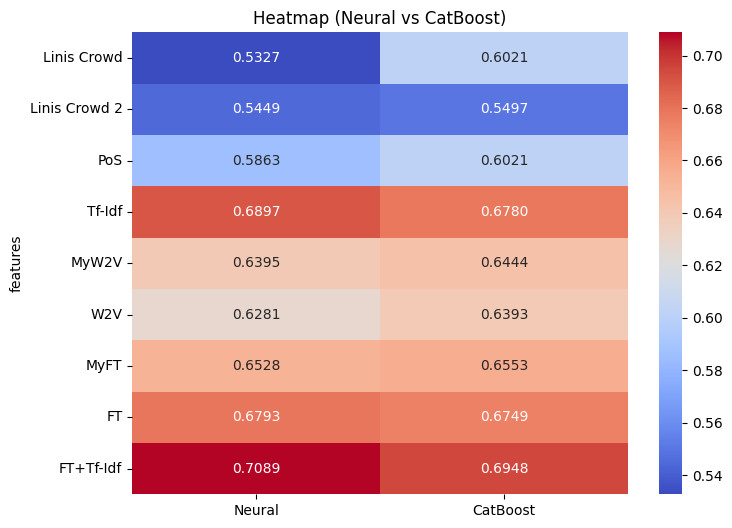

In [129]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.set_index('features'), annot=True, cmap="coolwarm", fmt=".4f")
plt.title("Heatmap (Neural vs CatBoost)")
plt.show()

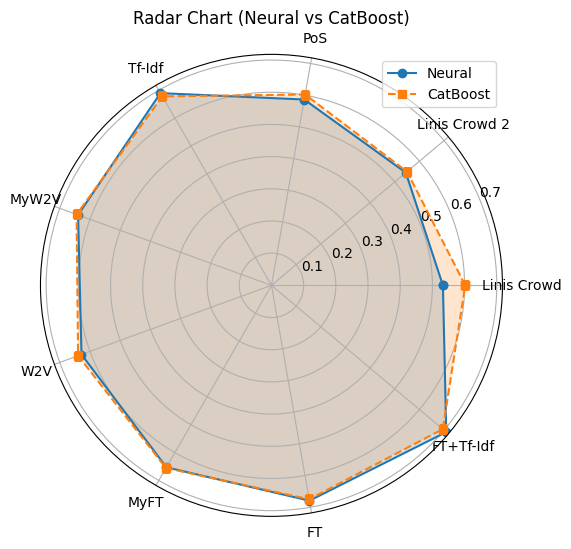

In [130]:
labels = df['features']
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

values_neural = df['Neural'].tolist()
values_catboost = df['CatBoost'].tolist()
values_neural += values_neural[:1]  # Замкнуть круг
values_catboost += values_catboost[:1]  
angles += angles[:1]  

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values_neural, label="Neural", linestyle='solid', marker='o')
ax.plot(angles, values_catboost, label="CatBoost", linestyle='dashed', marker='s')
ax.fill(angles, values_neural, alpha=0.2)
ax.fill(angles, values_catboost, alpha=0.2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Radar Chart (Neural vs CatBoost)")
plt.legend()
plt.show()

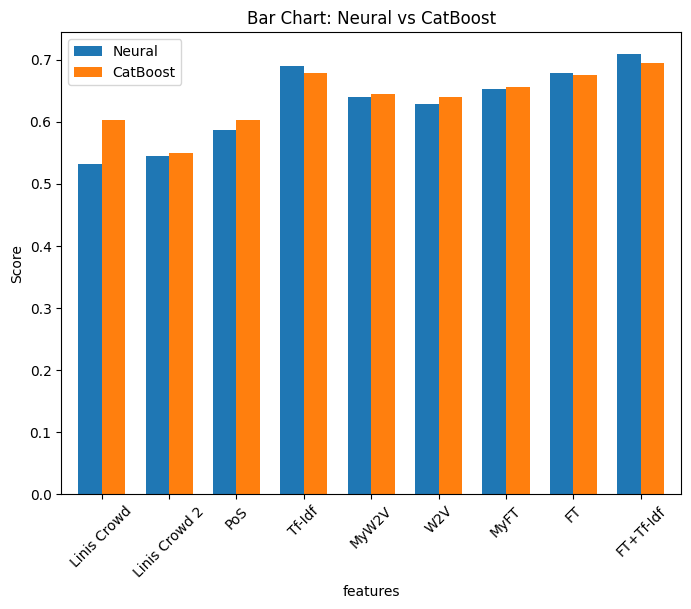

In [131]:
df.plot(x="features", kind="bar", figsize=(8, 6), width=0.7)
plt.title("Bar Chart: Neural vs CatBoost")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(["Neural", "CatBoost"])
plt.show()